# K Means

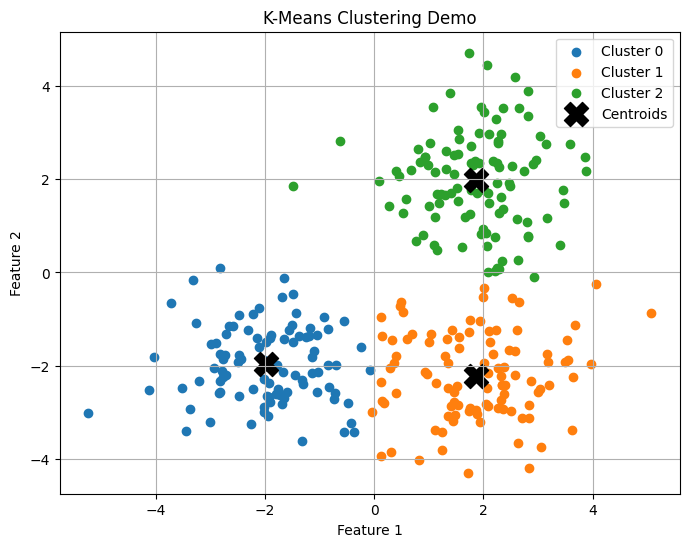

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# 1. Generate sample data
np.random.seed(42)
X = np.vstack([
    np.random.randn(100, 2) + [2, 2],
    np.random.randn(100, 2) + [-2, -2],
    np.random.randn(100, 2) + [2, -2]
])

# 2. Fit KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X)

# 3. Get cluster assignments and centroids
labels = kmeans.labels_
centroids = kmeans.cluster_centers_

# 4. Plot results
plt.figure(figsize=(8, 6))

# Plot data points coloured by cluster
for i in range(3):
    plt.scatter(
        X[labels == i][:, 0],
        X[labels == i][:, 1],
        label=f"Cluster {i}"
    )

# Plot centroids
plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    s=300,
    c='black',
    marker='X',
    label='Centroids'
)

plt.title("K-Means Clustering Demo")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()


# Hierachical clustering

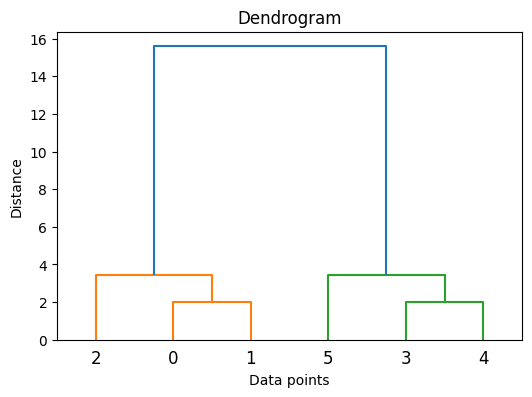

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

# --- Sample data (2D points) ---
X = np.array([
    [1, 2], [1, 4], [1, 0],
    [10, 2], [10, 4], [10, 0]
])

# --- Step 1: Create dendrogram ---
Z = linkage(X, method='ward')  # hierarchical clustering

plt.figure(figsize=(6, 4))
dendrogram(Z)
plt.title("Dendrogram")
plt.xlabel("Data points")
plt.ylabel("Distance")
plt.show()



Confusion Matrix:
[[ 60   3]
 [  7 101]]

Breakdown:
True Negative (TN): 60
False Positive (FP): 3
False Negative (FN): 7
True Positive (TP): 101


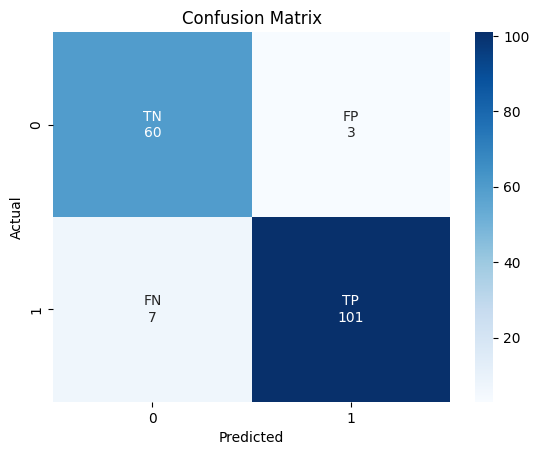


Metrics:
Accuracy: 0.942
Precision: 0.971
Recall: 0.935

Accuracy = (TP + TN) / (TP + TN + FP + FN)
Precision = TP / (TP + FP)
Recall = TP / (TP + FN)


In [ ]:
# Import libraries
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset (binary classification)
data = load_breast_cancer()
X = data.data
y = data.target

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Train Decision Tree
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

# Extract values
TN, FP, FN, TP = cm.ravel()

print("\nBreakdown:")
print(f"True Negative (TN): {TN}")
print(f"False Positive (FP): {FP}")
print(f"False Negative (FN): {FN}")
print(f"True Positive (TP): {TP}")

cm = np.array([[TN, FP],
               [FN, TP]])

labels = [[f"TN\n{TN}", f"FP\n{FP}"],
          [f"FN\n{FN}", f"TP\n{TP}"]]

plt.figure()
sns.heatmap(cm, annot=labels, fmt='', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()


# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print("\nMetrics:")
print(f"Accuracy: {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")

print("\nAccuracy = (TP + TN) / (TP + TN + FP + FN)")
print("Precision = TP / (TP + FP)")
print("Recall = TP / (TP + FN)")




# Decision Tree

In [ ]:
# Decision Tree

Actuals: 	 [1 1 0 1 0 0 0 1]
Predictions:	 [1 1 0 1 0 0 0 1]
Accuracy: 1.00


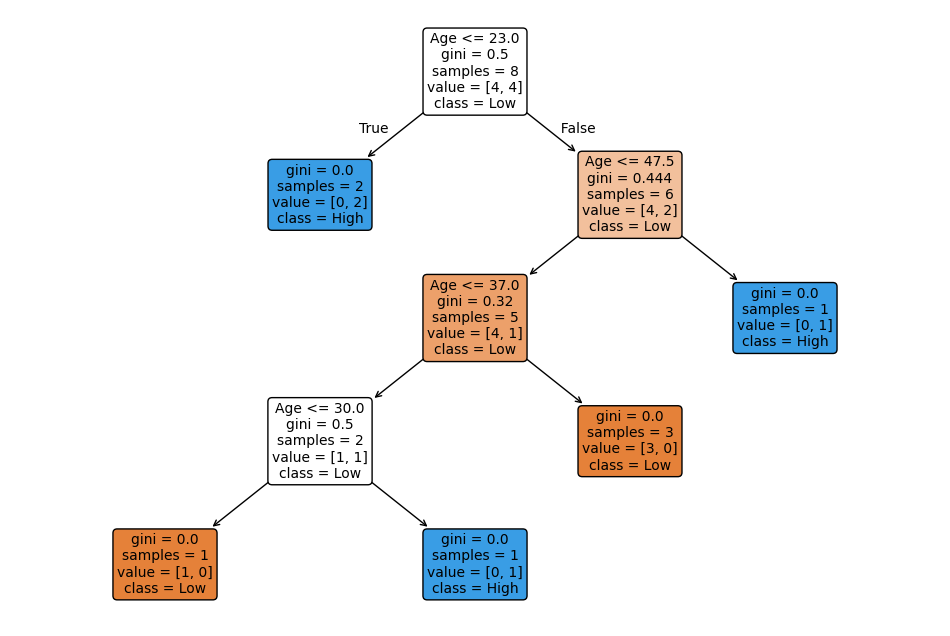

In [70]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

# --- Step 1: Create dataset ---
data = {
    "Age": [19, 21, 25, 35, 39, 41, 45, 50],
    "Gender": ["M", "F", "M", "F", "M", "F", "F", "M"],
    "Married": ["Y", "N", "N", "Y", "N", "Y", "Y", "N"],
    "Credit_risk": [1, 1, 0, 1, 0, 0, 0, 1]
}

df = pd.DataFrame(data)

# --- Step 2: Encode categorical variables ---
le_gender = LabelEncoder()
le_married = LabelEncoder()

df["Gender"] = le_gender.fit_transform(df["Gender"])   # M/F → 1/0
df["Married"] = le_married.fit_transform(df["Married"]) # Y/N → 1/0

# --- Step 3: Split features + target ---
X = df[["Age", "Gender", "Married"]]
y = df["Credit_risk"]

# --- Step 4: Train decision tree ---
model = DecisionTreeClassifier(max_depth=10)
model.fit(X, y)

print("Actuals: \t", y.values)
print("Predictions:\t", model.predict(X))
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y, model.predict(X))
print(f"Accuracy: {accuracy:.2f}")

# --- Step 5: Visualise tree ---
plt.figure(figsize=(12, 8))
plot_tree(
    model,
    feature_names=["Age", "Gender", "Married"],
    class_names=["Low", "High"],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.show()



# Random Forest

Actuals: 	 [1 1 0 1 0 0 0 1]
Predictions:	 [1 1 0 1 1 0 0 1]
Accuracy: 0.88


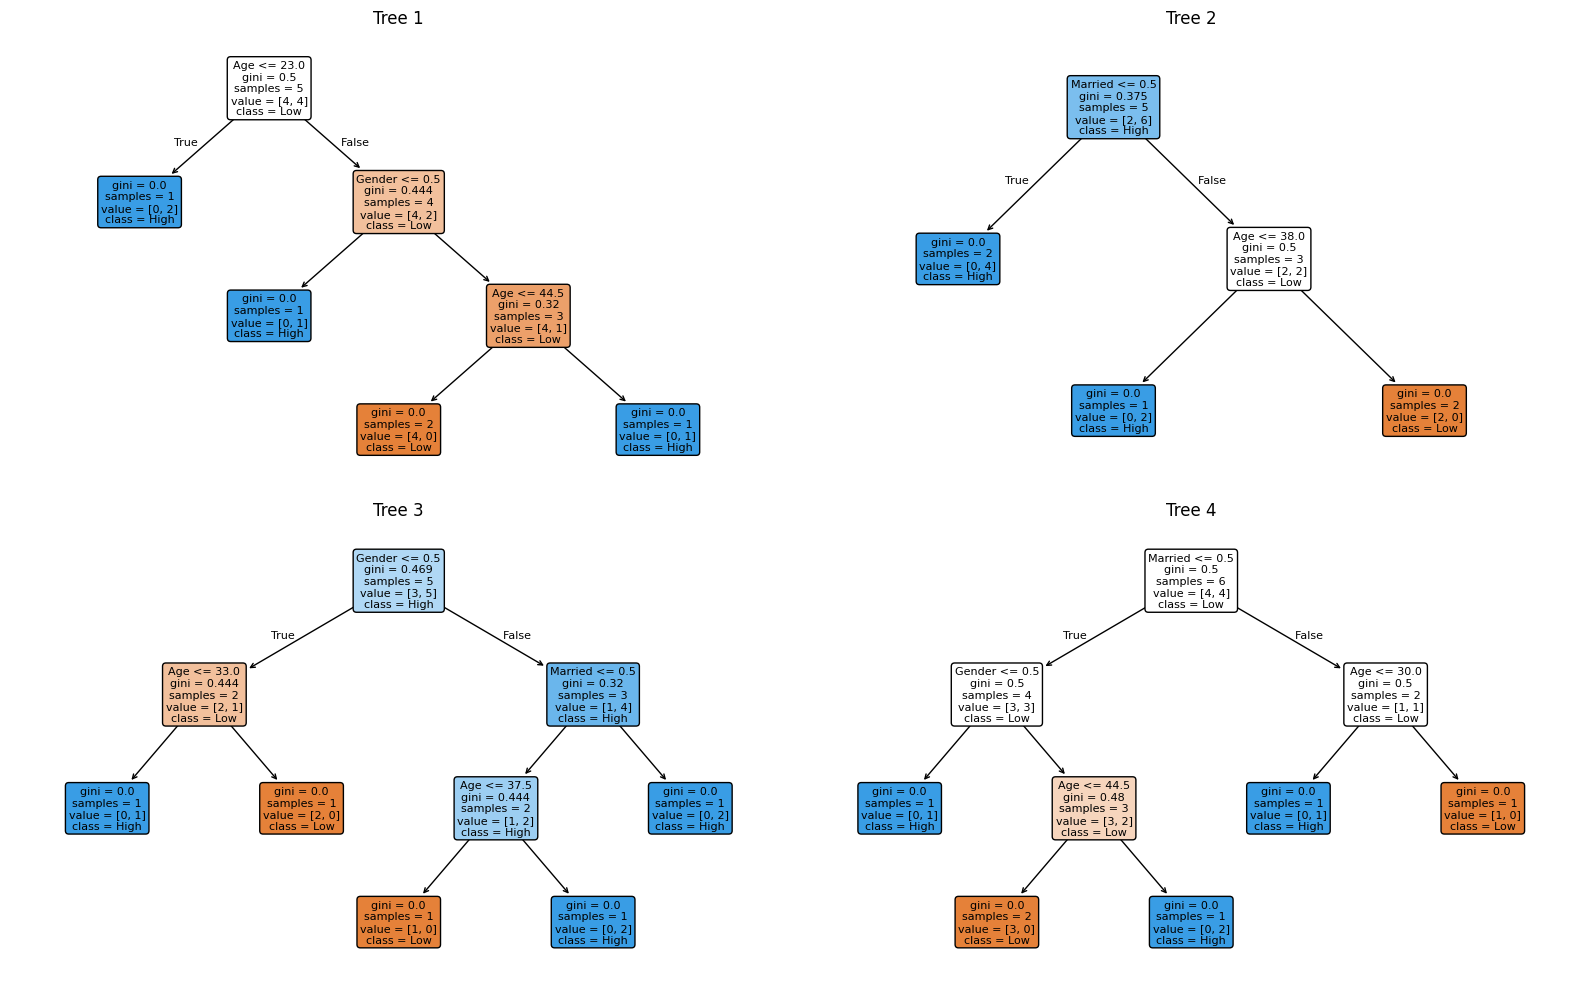

In [68]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# --- Step 1: Create dataset ---
data = {
    "Age": [19, 21, 25, 35, 39, 41, 45, 50],
    "Gender": ["M", "F", "M", "F", "M", "F", "F", "M"],
    "Married": ["Y", "N", "N", "Y", "N", "Y", "Y", "N"],
    "Credit_risk": [1, 1, 0, 1, 0, 0, 0, 1]
}

df = pd.DataFrame(data)

# --- Step 2: Encode categorical variables ---
le_gender = LabelEncoder()
le_married = LabelEncoder()

df["Gender"] = le_gender.fit_transform(df["Gender"])   # M/F → 1/0
df["Married"] = le_married.fit_transform(df["Married"]) # Y/N → 1/0

# --- Step 3: Split features + target ---
X = df[["Age", "Gender", "Married"]]
y = df["Credit_risk"]

# Train Random Forest
rf = RandomForestClassifier(n_estimators=5, max_depth=3, random_state=42)
rf.fit(X, y)

print("Actuals: \t", y.values)
print("Predictions:\t", rf.predict(X))
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y, rf.predict(X))
print(f"Accuracy: {accuracy:.2f}")


# --- Plot first 4 trees ---
plt.figure(figsize=(16, 10))

for i in range(4):
    plt.subplot(2, 2, i + 1)
    plot_tree(
        rf.estimators_[i],
        feature_names=["Age", "Gender", "Married"],
        class_names=["Low", "High"],
        filled=True,
        rounded=True,
        fontsize=8
    )
    plt.title(f"Tree {i+1}")

plt.tight_layout()
plt.show()



# Boosted Tree

Actuals: 	 [1 1 0 1 0 0 0 1]
Predictions:	 [1 1 0 1 0 0 0 1]
Accuracy: 1.00


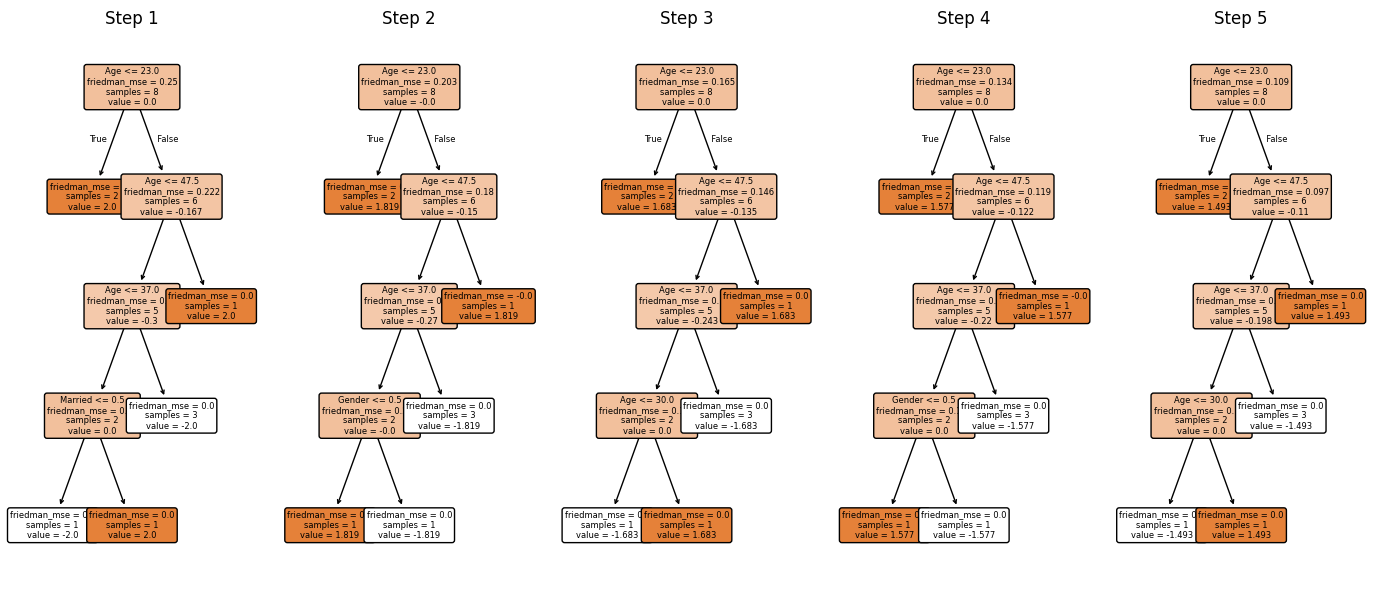

In [69]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Train boosting model
gb = GradientBoostingClassifier(n_estimators=5, max_depth=10, random_state=42)
gb.fit(X, y)

print("Actuals: \t", y.values)
print("Predictions:\t", gb.predict(X))
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y, gb.predict(X))
print(f"Accuracy: {accuracy:.2f}")


# --- Plot sequential trees ---
plt.figure(figsize=(14, 6))

for i, tree in enumerate(gb.estimators_[:, 0]):
    plt.subplot(1, 5, i + 1)
    plot_tree(
        tree,
        feature_names=["Age", "Gender", "Married"],
        class_names=["Low", "High"],
        filled=True,
        rounded=True,
        fontsize=6
    )
    plt.title(f"Step {i+1}")

plt.tight_layout()
plt.show()

# Decision Jungle

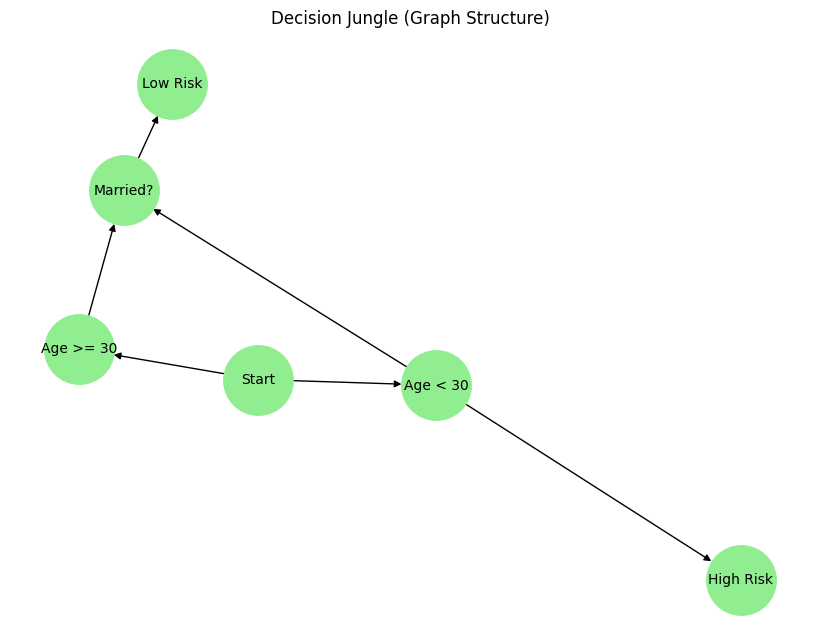

In [26]:
import networkx as nx
import matplotlib.pyplot as plt

# Create directed graph (jungle)
G = nx.DiGraph()

# Nodes (decisions)
G.add_node("Start")
G.add_node("Age < 30")
G.add_node("Age >= 30")
G.add_node("Married?")
G.add_node("High Risk")
G.add_node("Low Risk")

# Edges (flow paths)
G.add_edges_from([
    ("Start", "Age < 30"),
    ("Start", "Age >= 30"),

    # Diverging
    ("Age < 30", "High Risk"),
    ("Age >= 30", "Married?"),

    # Converging paths (this is the jungle difference)
    ("Married?", "Low Risk"),
    ("Age < 30", "Married?")  # merging path
])

# Draw graph
plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G, seed=42)

nx.draw(
    G, pos,
    with_labels=True,
    node_color="lightgreen",
    node_size=2500,
    font_size=10,
    arrows=True
)

plt.title("Decision Jungle (Graph Structure)")
plt.show()

# Bayes

Actuals: 	 [1 1 0 1 0 0 0 1]
Predictions:	 [1 1 1 0 0 0 0 0]
Accuracy: 0.62


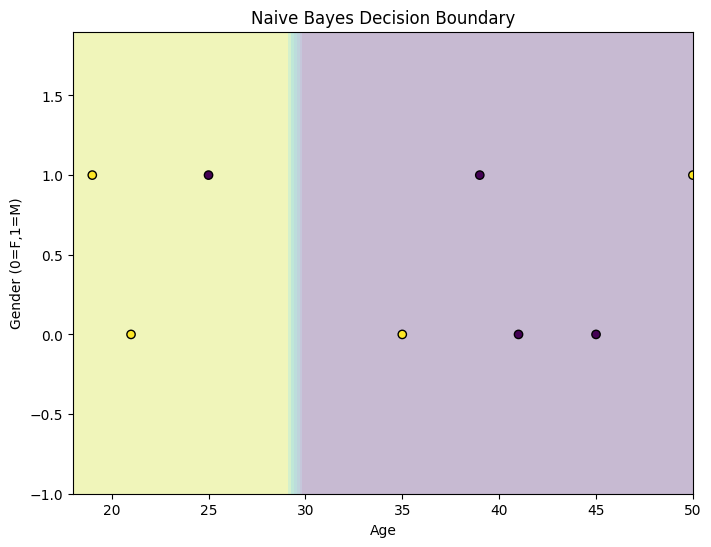

In [65]:

import pandas as pd
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

# --- Dataset ---
data = {
    "Age": [19, 21, 25, 35, 39, 41, 45, 50],
    "Gender": ["M", "F", "M", "F", "M", "F", "F", "M"],
    "Married": ["Y", "N", "N", "Y", "N", "Y", "Y", "N"],
    "Credit_risk": [1, 1, 0, 1, 0, 0, 0, 1]
}

df = pd.DataFrame(data)

# --- Encode categorical ---
le_g = LabelEncoder()
le_m = LabelEncoder()

df["Gender"] = le_g.fit_transform(df["Gender"])
df["Married"] = le_m.fit_transform(df["Married"])

X = df[["Age", "Gender", "Married"]]
y = df["Credit_risk"]

# --- Train Naive Bayes ---
model = GaussianNB()
model.fit(X, y)

# --- Predict ---
preds = model.predict(X)

print("Actuals: \t", y.values)
print("Predictions:\t", preds)
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y, preds)
print(f"Accuracy: {accuracy:.2f}")



import numpy as np

X_vis = df[["Age", "Gender"]].values
y_vis = y

model = GaussianNB()
model.fit(X_vis, y_vis)

# Create grid
x_min, x_max = X_vis[:, 0].min() - 1, X_vis[:, 0].max() + 1
y_min, y_max = X_vis[:, 1].min() - 1, X_vis[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 1),
    np.arange(y_min, y_max, 0.1)
)

Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X_vis[:, 0], X_vis[:, 1], c=y_vis, edgecolor='k')

plt.xlabel("Age")
plt.ylabel("Gender (0=F,1=M)")
plt.title("Naive Bayes Decision Boundary")
plt.show()


# Neural network

Actuals: 	 [1 1 0 1 0 0 0 1]
Predictions:	 [1 1 0 1 0 0 0 1]
Accuracy: 1.00


c:\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.



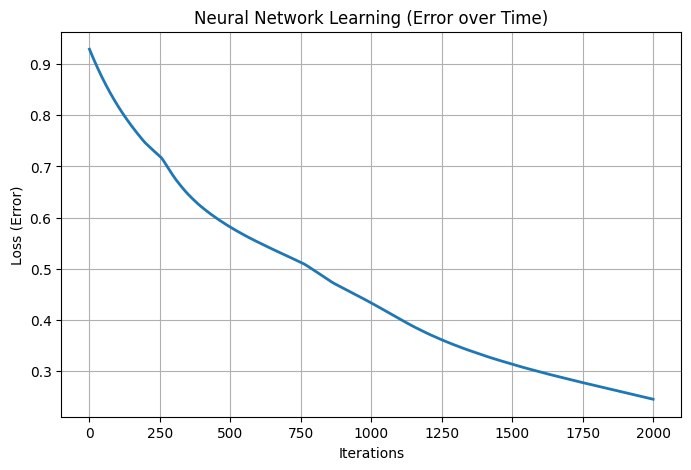

In [64]:
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler

# --- Features ---
X = df[["Age", "Gender", "Married"]]
y = df["Credit_risk"]

# --- Scale data (important for neural networks) ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- Train model ---
nn = MLPClassifier(hidden_layer_sizes=(3,), max_iter=2000, random_state=42)
nn.fit(X_scaled, y)

# --- Predictions ---
preds = nn.predict(X_scaled)
probs = nn.predict_proba(X_scaled)

print("Actuals: \t", y.values)
print("Predictions:\t", preds)

from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y, preds)
print(f"Accuracy: {accuracy:.2f}")


import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(nn.loss_curve_, linewidth=2)

plt.title("Neural Network Learning (Error over Time)")
plt.xlabel("Iterations")
plt.ylabel("Loss (Error)")

plt.grid(True)
plt.show()



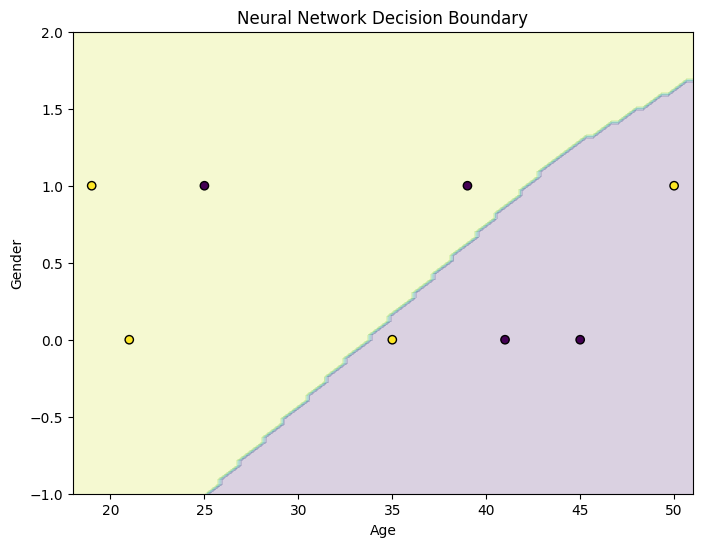

In [51]:
import numpy as np

# Use only Age + Gender
X2 = df[["Age", "Gender"]].values
X2_scaled = scaler.fit_transform(X2)

nn.fit(X2_scaled, y)

# Create grid
x_min, x_max = X2[:, 0].min() - 1, X2[:, 0].max() + 1
y_min, y_max = X2[:, 1].min() - 1, X2[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 100),
    np.linspace(y_min, y_max, 100)
)

grid = np.c_[xx.ravel(), yy.ravel()]
grid_scaled = scaler.transform(grid)

Z = nn.predict(grid_scaled)
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.2)
plt.scatter(X2[:, 0], X2[:, 1], c=y, edgecolor='black')

plt.title("Neural Network Decision Boundary")
plt.xlabel("Age")
plt.ylabel("Gender")
plt.show()

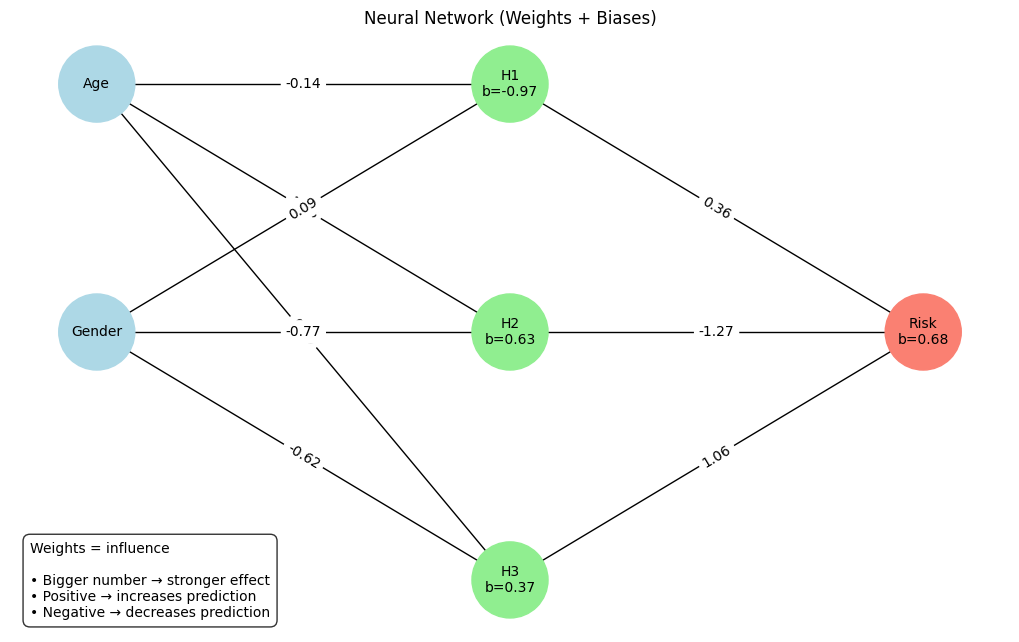

In [60]:
import matplotlib.pyplot as plt
import networkx as nx

# --- Extract weights & biases ---
W1 = nn.coefs_[0]   # input → hidden
W2 = nn.coefs_[1]   # hidden → output

b1 = nn.intercepts_[0]  # hidden biases
b2 = nn.intercepts_[1]  # output bias

# --- Node names ---
inputs = ["Age", "Gender"]
hidden = [f"H{i+1}" for i in range(W1.shape[1])]
output = ["Risk"]

G = nx.DiGraph()

# --- Add nodes with bias labels ---
for n in inputs:
    G.add_node(n, label=n)

for i, n in enumerate(hidden):
    G.add_node(n, label=f"{n}\nb={b1[i]:.2f}")  # ✅ bias on hidden

G.add_node("Risk", label=f"Risk\nb={b2[0]:.2f}")  # ✅ output bias

# --- Add edges with weights ---
for i, inp in enumerate(inputs):
    for j, hid in enumerate(hidden):
        G.add_edge(inp, hid, weight=round(W1[i, j], 2))

for j, hid in enumerate(hidden):
    G.add_edge(hid, "Risk", weight=round(W2[j, 0], 2))

# --- Layout ---
pos = {}

for i, n in enumerate(inputs):
    pos[n] = (0, -i)

for i, n in enumerate(hidden):
    pos[n] = (1, -i)

pos["Risk"] = (2, -1)

# --- Extract labels ---
node_labels = nx.get_node_attributes(G, 'label')
edge_labels = nx.get_edge_attributes(G, 'weight')

# --- Draw ---
plt.figure(figsize=(10, 6))

nx.draw(
    G, pos,
    labels=node_labels,
    node_color=["lightblue"]*len(inputs) + ["lightgreen"]*len(hidden) + ["salmon"],
    node_size=3000,
    font_size=10,
    arrows=False
)

nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

plt.title("Neural Network (Weights + Biases)")

# ✅ Legend text
legend_text = (
    "Weights = influence\n\n"
    "• Bigger number → stronger effect\n"
    "• Positive → increases prediction\n"
    "• Negative → decreases prediction"
)

# ✅ Draw text box in bottom-left
plt.text(
    0.02, 0.02, legend_text,
    transform=plt.gca().transAxes,
    fontsize=10,
    verticalalignment='bottom',
    bbox=dict(
        boxstyle="round,pad=0.5",
        facecolor="white",
        edgecolor="black",
        alpha=0.8
    )
)

plt.axis('off')
plt.show()



# Interactive Demo

In [ ]:
https://playground.tensorflow.org/

# SVM

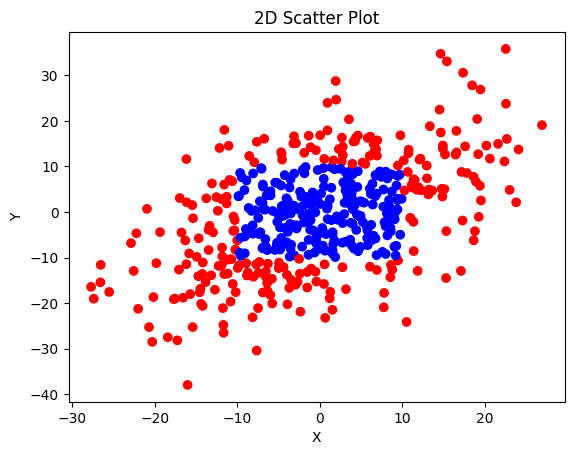

In [72]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Create random data
np.random.seed(0)
X = np.random.normal(0, 10, 500)
Y = X * 0.6 + np.random.normal(0, 10, len(X))

# Convert to DataFrame
df = pd.DataFrame({'X': X, 'Y': Y})

# Mark the middle records
df['Type'] = 'red'
mask = (df['X'] > -10) & (df['X'] < 10) & (df['Y'] > -10) & (df['Y'] < 10)
df.loc[mask, 'Type'] = 'blue'

# 2D scatter plot
colors = df['Type'].map({'red': 'red', 'blue': 'blue'})
plt.scatter(df['X'], df['Y'], c=colors)
plt.xlabel('X')
plt.ylabel('Y')
plt.title('2D Scatter Plot')
plt.show()


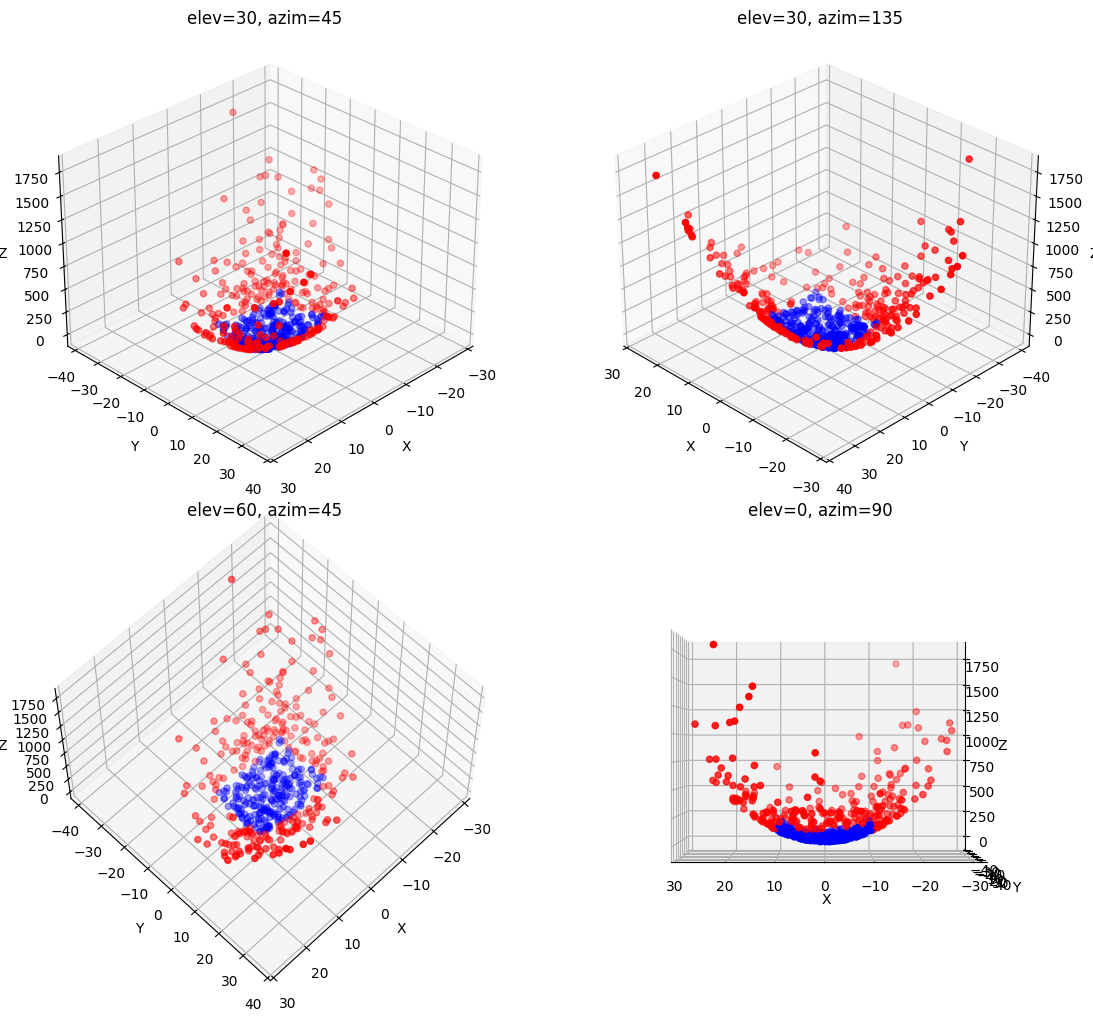

In [74]:
fig = plt.figure(figsize=(12, 10))

views = [
    (30, 45),
    (30, 135),
    (60, 45),
    (0, 90)
]

for i, (elev, azim) in enumerate(views, 1):
    ax = fig.add_subplot(2, 2, i, projection='3d')
    ax.scatter(df['X'], df['Y'], df['Z'], c=colors)
    ax.view_init(elev=elev, azim=azim)
    ax.set_title(f'elev={elev}, azim={azim}')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')

plt.tight_layout()
plt.show()

In [78]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from sklearn.linear_model import LinearRegression

# Data
np.random.seed(0)
X = np.random.normal(0, 10, 500)
Y = X * 0.6 + np.random.normal(0, 10, len(X))

df = pd.DataFrame({'X': X, 'Y': Y})
df['Z'] = df['X']**2 + df['Y']**2

# Colouring
df['Type'] = 'red'
mask = (df['X'] > -10) & (df['X'] < 10) & (df['Y'] > -10) & (df['Y'] < 10)
df.loc[mask, 'Type'] = 'blue'

colors = df['Type'].map({'red': 'red', 'blue': 'blue'})

# --- Fit plane: Z = aX + bY + c ---
reg = LinearRegression()
reg.fit(df[['X', 'Y']], df['Z'])

# Create grid for plane
x_range = np.linspace(df['X'].min(), df['X'].max(), 30)
y_range = np.linspace(df['Y'].min(), df['Y'].max(), 30)
xx, yy = np.meshgrid(x_range, y_range)
zz = reg.intercept_ + reg.coef_[0]*xx + reg.coef_[1]*yy

# --- Plot ---
fig = go.Figure()

# Scatter points
fig.add_trace(go.Scatter3d(
    x=df['X'],
    y=df['Y'],
    z=df['Z'],
    mode='markers',
    marker=dict(size=4, color=colors),
    name='Points'
))

# Hyperplane surface
fig.add_trace(go.Surface(
    x=xx,
    y=yy,
    z=zz,
    opacity=0.5,
    showscale=False,
    name='Hyperplane'
))

fig.update_layout(
    title='3D Scatter with Fitted Hyperplane',
    scene=dict(
        xaxis_title='X',
        yaxis_title='Y',
        zaxis_title='Z'
    )
)

fig.show()